In [2]:
from pathlib import Path
import os
import sys

BASE_DIR = Path.cwd()
MODEL_ID = "kauffinger/xlm-roberta-base-finetuned-enron"
DATASET_PATH = BASE_DIR / "Dataset source" / "training" / "Dataset_SMS_clean.csv"
MODEL_OUTPUT_DIR = BASE_DIR / ".hf_models" / "finetuned_xlm_roberta_sms_spam"
MODEL_CACHE_DIR = BASE_DIR / ".hf_models"
MODEL_CACHE_DIR.mkdir(exist_ok=True)
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("HF_HOME", str(MODEL_CACHE_DIR / "home"))
os.environ.setdefault("HF_HUB_CACHE", str(MODEL_CACHE_DIR / "hub"))
os.environ.setdefault("HF_XET_CACHE", str(MODEL_CACHE_DIR / "xet"))
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")
os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

TEST_SIZE = 0.2
RANDOM_STATE = 42
MAX_LENGTH = 160
NUM_EPOCHS = 3
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
LABEL2ID = {"ham": 0, "spam": 1}
ID2LABEL = {0: "ham", 1: "spam"}
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

assert "py310" in str(sys.executable).lower(), f"Please run this notebook with Anaconda py310. Current: {sys.executable}"

df = pd.read_csv(DATASET_PATH, encoding="utf-8-sig")
df = df.dropna(subset=["Category", "Message"]).copy()
df["Category"] = df["Category"].astype(str).str.strip().str.lower()
df["Message"] = df["Message"].astype(str).str.strip()
df = df[df["Category"].isin(LABEL2ID)]
df = df[df["Message"] != ""]
df["label"] = df["Category"].map(LABEL2ID)

x_train, x_test, y_train, y_test = train_test_split(
    df["Message"],
    df["label"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df["label"],
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, cache_dir=str(MODEL_CACHE_DIR))
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_ID,
    cache_dir=str(MODEL_CACHE_DIR),
    num_labels=2,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    use_safetensors=True,
)
model.to(DEVICE)

class SmsDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            list(texts.astype(str)),
            truncation=True,
            padding=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels.to_numpy(), dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: value[idx] for key, value in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

train_dataset = SmsDataset(x_train.reset_index(drop=True), y_train.reset_index(drop=True))
test_dataset = SmsDataset(x_test.reset_index(drop=True), y_test.reset_index(drop=True))
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

class_counts = y_train.value_counts().sort_index().to_numpy()
class_weights = len(y_train) / (len(class_counts) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float, device=DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, int(total_steps * 0.1)),
    num_training_steps=total_steps,
)


def predict_loader(loader):
    model.eval()
    all_predictions = []
    all_labels = []
    with torch.inference_mode():
        for batch in loader:
            labels = batch.pop("labels").to(DEVICE)
            inputs = {key: value.to(DEVICE) for key, value in batch.items()}
            logits = model(**inputs).logits
            predictions = logits.argmax(dim=-1)
            all_predictions.extend(predictions.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
    return np.array(all_labels), np.array(all_predictions)

best_macro_f1 = -1.0
for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    for batch in train_loader:
        labels = batch.pop("labels").to(DEVICE)
        inputs = {key: value.to(DEVICE) for key, value in batch.items()}
        optimizer.zero_grad(set_to_none=True)
        logits = model(**inputs).logits
        loss = torch.nn.functional.cross_entropy(logits, labels, weight=class_weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    eval_labels, eval_predictions = predict_loader(test_loader)
    eval_accuracy = accuracy_score(eval_labels, eval_predictions)
    eval_macro_f1 = f1_score(eval_labels, eval_predictions, average="macro", zero_division=0)
    print(
        f"Epoch {epoch}/{NUM_EPOCHS} - "
        f"loss: {total_loss / len(train_loader):.4f} - "
        f"eval_accuracy: {eval_accuracy:.4f} - "
        f"eval_macro_f1: {eval_macro_f1:.4f}"
    )
    if eval_macro_f1 > best_macro_f1:
        best_macro_f1 = eval_macro_f1
        model.save_pretrained(str(MODEL_OUTPUT_DIR), safe_serialization=True)
        tokenizer.save_pretrained(str(MODEL_OUTPUT_DIR))

model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_OUTPUT_DIR))
model.to(DEVICE)

train_labels, train_predictions = predict_loader(train_loader)
test_labels, predictions = predict_loader(test_loader)

train_accuracy = accuracy_score(train_labels, train_predictions)
test_accuracy = accuracy_score(test_labels, predictions)
report_df = pd.DataFrame(
    classification_report(
        test_labels,
        predictions,
        target_names=[ID2LABEL[0], ID2LABEL[1]],
        output_dict=True,
        zero_division=0,
    )
).transpose()

print(f"Training sample: {len(x_train)}")
print(f"Test sample: {len(x_test)}")
print(f"Training accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Saved fine-tuned model to: {MODEL_OUTPUT_DIR}")

report_df

c:\ProgramData\anaconda3\envs\py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\LCZ\AppData\Roaming\Python\Python310\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Epoch 1/3 - loss: 0.5636 - eval_accuracy: 0.9874 - eval_macro_f1: 0.9707
Epoch 2/3 - loss: 0.0830 - eval_accuracy: 0.9884 - eval_macro_f1: 0.9727
Epoch 3/3 - loss: 0.0290 - eval_accuracy: 0.9874 - eval_macro_f1: 0.9709
Training sample: 4120
Test sample: 1031
Training accuracy: 0.9983
Test accuracy: 0.9884
Saved fine-tuned model to: d:\Project\Leeds\Msc Project\.hf_models\finetuned_xlm_roberta_sms_spam


,precision,recall,f1-score,support
ham,0.990099,0.996678,0.993377,903.000000
spam,0.975410,0.929688,0.952000,128.000000
accuracy,0.988361,0.988361,0.988361,0.988361
macro avg,0.982754,0.963183,0.972689,1031.000000
weighted avg,0.988275,0.988361,0.988240,1031.000000


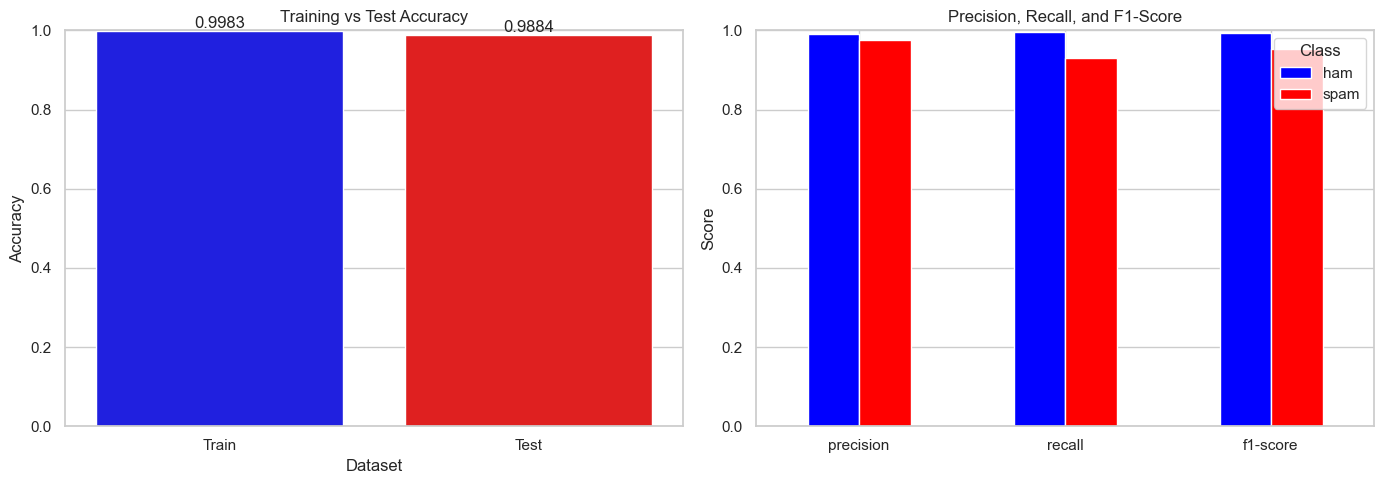

,precision,recall,f1-score,support
ham,0.990099,0.996678,0.993377,903.000000
spam,0.975410,0.929688,0.952000,128.000000
accuracy,0.988361,0.988361,0.988361,0.988361
macro avg,0.982754,0.963183,0.972689,1031.000000
weighted avg,0.988275,0.988361,0.988240,1031.000000


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
accuracy_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_accuracy, test_accuracy],
})
sns.barplot(data=accuracy_df, x="Dataset", y="Accuracy", hue="Dataset", palette=["blue", "red"], ax=axes[0], legend=False)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_title("Training vs Test Accuracy")
axes[0].set_ylabel("Accuracy")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.4f")

metrics_df = report_df.loc[["ham", "spam"], ["precision", "recall", "f1-score"]].transpose()
metrics_df.plot(kind="bar", ax=axes[1], color=["blue", "red"])
axes[1].set_ylim(0.0, 1.0)
axes[1].set_title("Precision, Recall, and F1-Score")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Class")

plt.tight_layout()
plt.show()

report_df

In [10]:
@torch.inference_mode()
def predict_message(text):
    model.eval()
    inputs = tokenizer(text, truncation=True, max_length=MAX_LENGTH, return_tensors="pt")
    inputs = {key: value.to(model.device) for key, value in inputs.items()}
    logits = model(**inputs).logits
    prediction_id = int(logits.argmax(dim=-1).cpu().item())
    return ID2LABEL[prediction_id]

# test_text = "Congratulations! You have won a free prize. Reply now to claim it."
#test_text = "Congrats! Youve been selected for a remote task role. Earn daily income by rating hotels. Start today!"
#test_text = "Dear Customer your pyatm wallet Has been booked and hold Your amount please complete your kyc contact customer care 7044518857"
test_text = "Your [chuanzhao li] verification code is: 123456. If you did not request this, secure your account here"

prediction = predict_message(test_text)
print(prediction)

spam
